# Particle Boundary Size Analysis

In [1]:
# If playNano isn't installed ensure this notebook is opened from the
# repository root and uncomment the installation line.
# Install in editable mode if developing:
# !pip install -e .

from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib import animation

from playnano.afm_stack import AFMImageStack
from playnano.processing.pipeline import ProcessingPipeline
from playnano.analysis.pipeline import AnalysisPipeline

from playnano.io.export_data import (
    save_ome_tiff_stack,
    save_npz_bundle,
    save_h5_bundle,
)
from playnano.analysis.export import export_analysis_to_json
from playnano.analysis.utils.particles import (
    flatten_particle_features,
    plot_particle_labels_3d,
)


In [2]:
data_path = r"C:\Users\ggjh246\OneDrive - University of Leeds\Data\my_data\2025-11-06\save-2025.11.06-15.37.45.220.h5-jpk"

channel = 'height_trace'  # common HS-AFM height channel

stack = AFMImageStack.load_data(data_path, channel=channel)
# stack = AFMImageStack.load_data(your_path, channel="height_trace") # uncomment this to use your_path

print(f"Loaded {stack.n_frames} frames; each frame shape: {stack.image_shape}")
print(f"Pixel size: {stack.pixel_size_nm} nm")
# print(stack.frame_metadata)


Loaded 262 frames; each frame shape: (256, 256)
Pixel size: 0.5859375 nm


Frame 0 metadata: {'timestamp': 0.0, 'line_rate': 120.0}


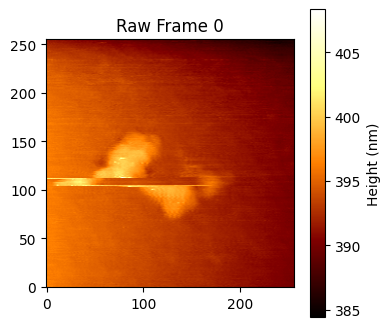

In [3]:

frame0 = stack.get_frame(0)
meta0 = stack.get_frame_metadata(0)
print("Frame 0 metadata:", meta0)
plt.figure(figsize=(4,4))
plt.imshow(frame0, cmap="afmhot", origin="lower")
plt.title("Raw Frame 0")
plt.colorbar(label="Height (nm)")
plt.show()


In [4]:
# Restore raw data
# Restore raw data if available
raw_data = stack.processed.get('raw')
if raw_data is not None:
    stack.data = raw_data


pipe = ProcessingPipeline(stack)
pipe.add_filter('topostats_filter')
pipe.add_filter('drop_frame_range', start=0, end=20)
#pipe.add_filter('align_frames', reference_frame = 20, pre_filter_sigma= 4, max_jump= 8)
#pipe.add_filter('intersection_crop', pad=(0,20))
#pipe.add_filter('replace_nan', mode='zero')

proc_record = pipe.run()

# The processing steps and the associated parameters are stored
# within the 'providence' AFMImageStack attirbute.
# Acessing this provides are record of the processing steps used.
print("Processing steps executed with parameters:")
for step in stack.provenance['processing']['steps']:
    print(f" • {step['name']}: {step['params']}")

Processing steps executed with parameters:
 • topostats_filter: {}
 • drop_frame_range: {'start': 0, 'end': 20}


## Analysis

In [5]:

p = AnalysisPipeline()
p.add("feature_detection", mask_fn="mask_mean_offset", factor=3, min_size=300, fill_holes=True)
p.add("particle_tracking", max_distance=80)
p.add("particle_boundary_size", threshold=66)

record = p.run(stack)

out = record["analysis"]["step_3_particle_boundary_size"]
out["summary"], out["flat_table"][:3]


({'n_tracks': 4,
  'n_rows': 242,
  'n_skipped_index_errors': 0,
  'n_missing_region_measurements': 0,
  'state_included': True},
 [{'track_id': 0,
   'label': 1,
   'frame': 1,
   'timestamp': 44.8,
   'max_dim': 24.0,
   'state': 0},
  {'track_id': 1,
   'label': 2,
   'frame': 1,
   'timestamp': 44.8,
   'max_dim': 111.0,
   'state': 1},
  {'track_id': 1,
   'label': 1,
   'frame': 2,
   'timestamp': 46.93333333333333,
   'max_dim': 127.0,
   'state': 1}])

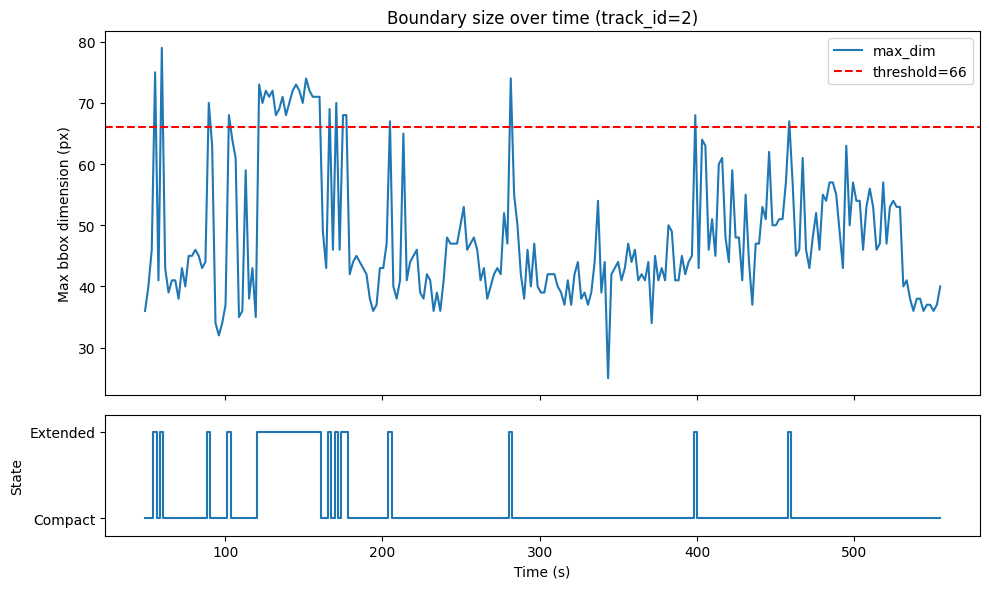

In [6]:
from playnano_plugins.plotting import plot_boundary_over_time, plot_boundary_over_time_multiple_tracks, animate_boundary_size_crop

fig = plot_boundary_over_time(out, track_id=2, x="timestamp")


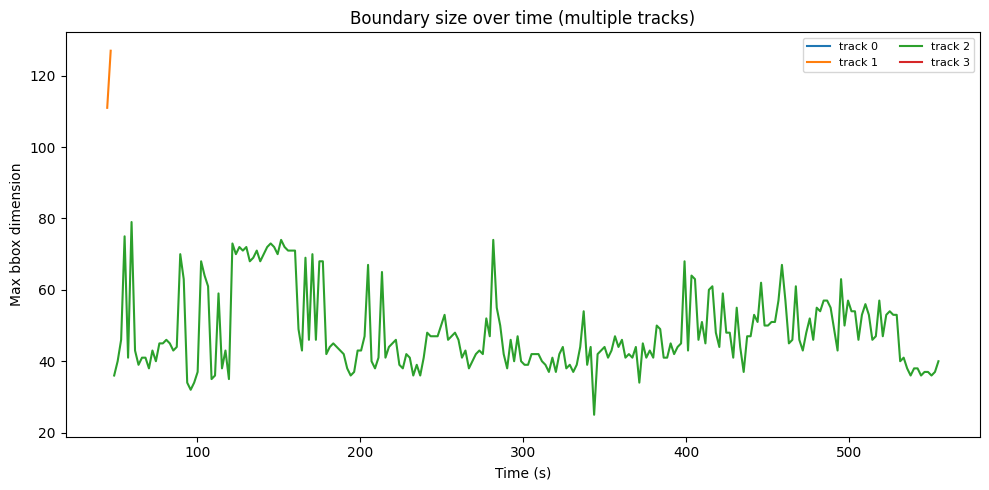

In [7]:
fig2 = plot_boundary_over_time_multiple_tracks(out, x="timestamp")

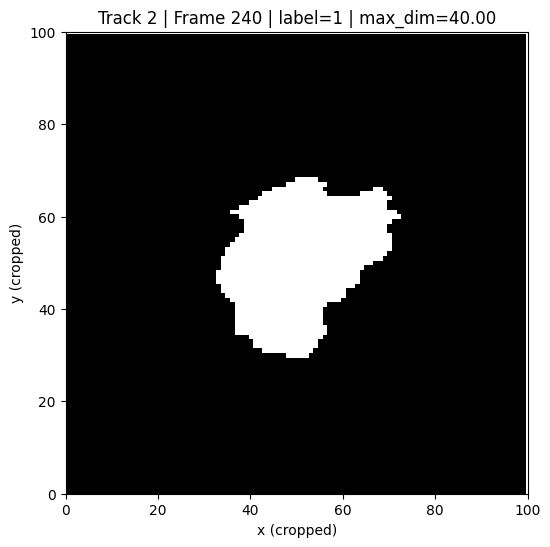

In [13]:
out = record["analysis"]["step_3_particle_boundary_size"]

fd =  record["analysis"]["step_1_feature_detection"]

fig, anim = animate_boundary_size_crop(
    boundary_out=out,
    masks=fd["labeled_masks"],
    track_id=2,
    crop_size=100,
    fps=6,
    save_path= "./track2.gif"
)
plt.show()
